# Image Classification
___

In [1]:
#Library Import
import tensorflow as tf
import PIL
from PIL import Image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Dropout, Dense, Softmax)
from tensorflow.keras.applications import mobilenet as _mobilenet
import random
import os
import numpy as np
from subprocess import call
import scipy
import matplotlib.pyplot as plt
from matplotlib import cm
import math
from decimal import Decimal, localcontext
from pathlib import Path

def opF(path):
    p = Path(path)
    os.startfile(p) # for Windows
    #_ = call(['open',p]) # for Mac/Linux

In [2]:
# Define the model architecture with changes to the output layer
model = tf.keras.applications.mobilenet.MobileNet(
    input_shape=(224, 224, 3), 
    include_top=False, 
    pooling='avg'
)

# Modify the model with additional layers
x = Dropout(rate=0.4)(model.output)
x = Dense(5)(x)
x = Softmax()(x)
model = Model(model.inputs, x)

# Compile the model after making changes
from tensorflow.keras.optimizers import Adam
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']  # Added metrics for monitoring training performance
)

# Ensure folders exist before creating datasets
def ensure_folder_exists(folder_path):
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)

# Define the paths for your new locations (outside the 'Datasets' folder)
train_folder = r'E:/OneDrive/Documents/007-Study Life/001-Urban Design/RC11_SkillsClasses/Workshop2/training_aug'
validation_folder = r'E:/OneDrive/Documents/007-Study Life/001-Urban Design/RC11_SkillsClasses/Workshop2/validation_aug'

# Ensure the folders for training and validation datasets exist
ensure_folder_exists(train_folder)
ensure_folder_exists(validation_folder)

# Initialize ImageDataGenerator
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet.preprocess_input,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1  # 10% for validation
)

# Set up the flow_from_directory for the training dataset
training = datagen.flow_from_directory(
    r'E:/OneDrive/Documents/007-Study Life/001-Urban Design/RC11_SkillsClasses/Workshop2/Datasets',  # Original Dataset Path
    target_size=(224, 224),
    save_to_dir=train_folder,  # Save augmented images to 'training_aug' folder in Workshop2
    subset='training'
)

# Set up the flow_from_directory for the validation dataset
validation = datagen.flow_from_directory(
    r'E:/OneDrive/Documents/007-Study Life/001-Urban Design/RC11_SkillsClasses/Workshop2/Datasets',  # Original Dataset Path
    target_size=(224, 224),
    save_to_dir=validation_folder,  # Save augmented images to 'validation_aug' folder in Workshop2
    subset='validation'
)

Found 1285 images belonging to 5 classes.
Found 141 images belonging to 5 classes.


In [4]:
# Train the model
batch_size = 32
history = model.fit(
    training,
    epochs=20,
    validation_data=validation,
)

C:\Users\Patrick\anaconda3\envs\urbandesignenv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


C:\Users\Patrick\anaconda3\envs\urbandesignenv\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


41/41 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7877 - loss: 0.7236 - val_accuracy: 0.5816 - val_loss: 5.8411
Epoch 2/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.8902 - loss: 0.3927 - val_accuracy: 0.7730 - val_loss: 2.5413
Epoch 3/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.9359 - loss: 0.1874 - val_accuracy: 0.9433 - val_loss: 0.4518
Epoch 4/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9525 - loss: 0.1419 - val_accuracy: 0.9645 - val_loss: 0.1386
Epoch 5/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9590 - loss: 0.1181 - val_accuracy: 0.8865 - val_loss: 0.4134
Epoch 6/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.9665 - loss: 0.0979 - val_accuracy: 0.8511 - val_loss: 1.2183
Epoch 7/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9741 - loss: 0.0907 - val_accuracy: 0.9078 - val_loss: 0.4615
Epoch 8/20
41/41 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.9835 - loss: 0.0592 - val_accuracy: 0.8723 - val_loss: 0.9562
Epo

In [5]:
training.class_indices

{'Fossil': 0, 'Pattern': 1, 'Place in Athens': 2, 'Pottery': 3, 'Sculpture': 4}

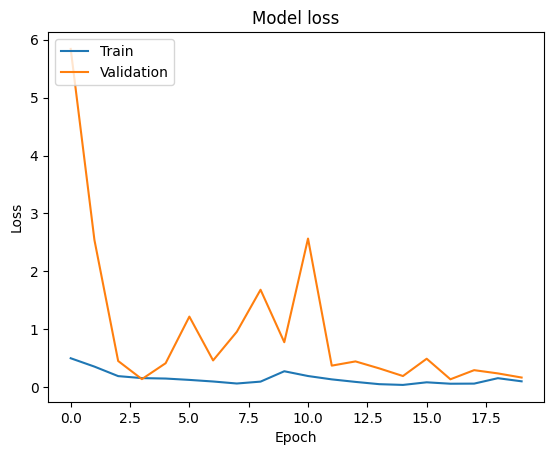

In [6]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

#### Saving History

In [16]:
# Ensure the "Pickle" folder exists
os.makedirs('Pickle', exist_ok=True)
# Save the trained model to the "Pickle" folder
model.save(os.path.join('Pickle', 'trained_model.h5'))

### Testing

In [8]:
def load_image(img_file, target_size=(224,224)):
    X = np.zeros((1, *target_size, 3))
    X[0, ] = np.asarray(tf.keras.preprocessing.image.load_img(
        img_file, 
        target_size=target_size)
    )
    X = tf.keras.applications.mobilenet.preprocess_input(X)
    return X

def ensure_folder_exists(folder):
    if not os.path.exists(folder):
        os.makedirs(folder)

In [ ]:
random_item = random.choice(os.listdir(r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\JPG"))
item_path = os.path.join(r"E:\OneDrive\Documents\007-Study Life\001-Urban Design\RC11_Thesis_Project\JPG",random_item)
item = load_image(item_path)

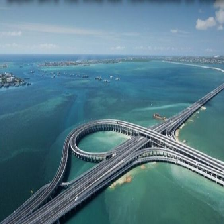

In [10]:
tf.keras.preprocessing.image.load_img(item_path, target_size=(224,224))

In [13]:
print(f'''Relation to: \nFossil:Pattern:Place in Athens:Pottery:Sculpture\n{np.round(model.predict(item),2)}''')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Relation to: 
Fossil:Pattern:Place in Athens:Pottery:Sculpture
[[0.33 0.06 0.25 0.27 0.09]]
